# OCR Module Test
This notebook allows you to test the `PlateRecognizer` module on a static image of a car.

In [1]:
import cv2
import matplotlib.pyplot as plt
import sys
import numpy as np
from PIL import Image

# Add parent directory for src imports
sys.path.append('..')

from src.ocr import PlateRecognizer

In [2]:
plate_reader = PlateRecognizer()  # No args needed

[20:41:16] INFO [tvd.ocr] Initializing EasyOCR for Plate Recognition...


In [3]:
image_path = r"C:\Users\Lenovo\Downloads\mumbai-two-cars-with-same-number-plate-found-outside-taj-mahal-hotel.avif"

# Load using PIL (since OpenCV can't read AVIF)
img = Image.open(image_path).convert("RGB")
frame = np.array(img)
frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

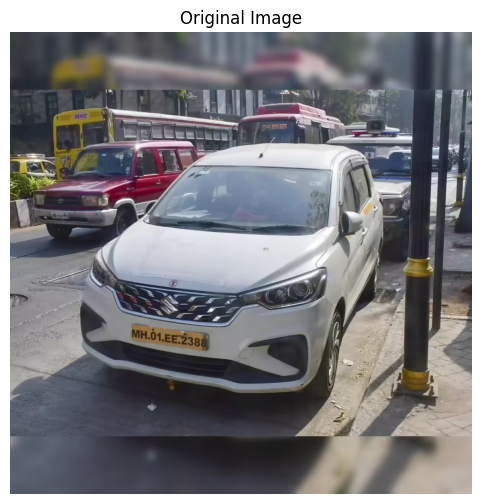

In [4]:
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')
plt.show()

In [5]:
h, w = frame.shape[:2]
bbox = [0, 0, w, h]

In [6]:
print("Running OCR...\n")

plate_text = plate_reader.process_vehicle(
    vehicle_id=999,
    frame=frame,
    bbox=bbox
)

Running OCR...



[20:41:53] INFO [tvd.ocr] Vehicle 999 -> Plate Detected: MHO1EE2388 (Conf: 0.43)


In [8]:
# OUTPUT RESULT
# ─────────────────────────────────────────────
print("--- OCR RESULT ---")
if plate_text:
    print(f" Detected Plate Number: {plate_text}")
else:
    print(" No plate detected or text not valid")

--- OCR RESULT ---
 Detected Plate Number: MHO1EE2388
